In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Tong so mau: 16,175


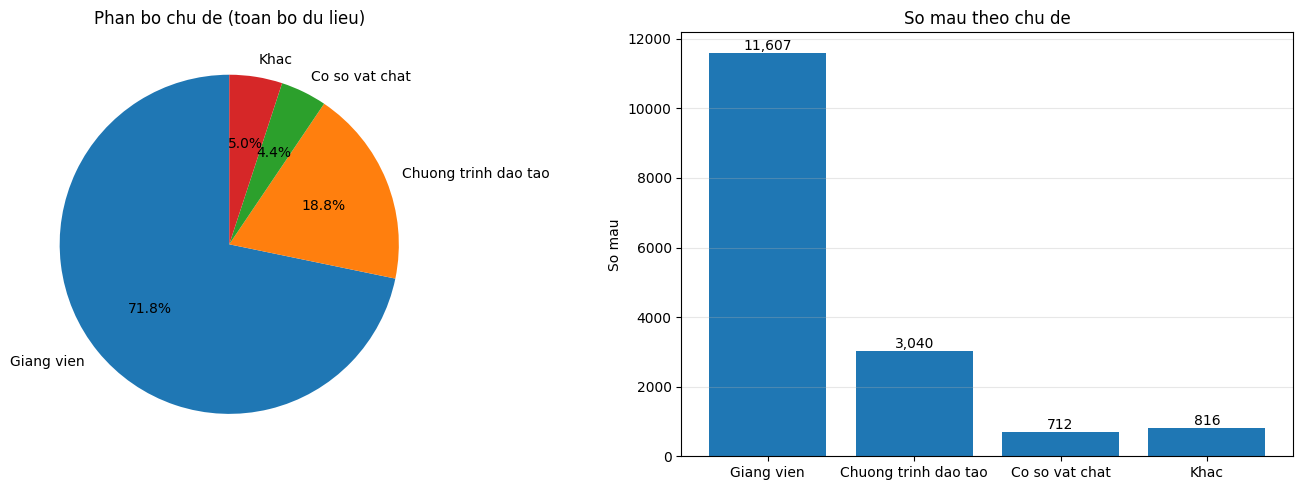

Bang dem sentiment x topic:


,Tieu cuc,Trung tinh,Tich cuc
Giang vien,4105,292,7210
Chuong trinh dao tao,2328,162,550
Co so vat chat,681,13,18
Khac,325,231,260


Ti le % sentiment ben trong tung topic:


,Tieu cuc,Trung tinh,Tich cuc
Giang vien,35.37,2.52,62.12
Chuong trinh dao tao,76.58,5.33,18.09
Co so vat chat,95.65,1.83,2.53
Khac,39.83,28.31,31.86


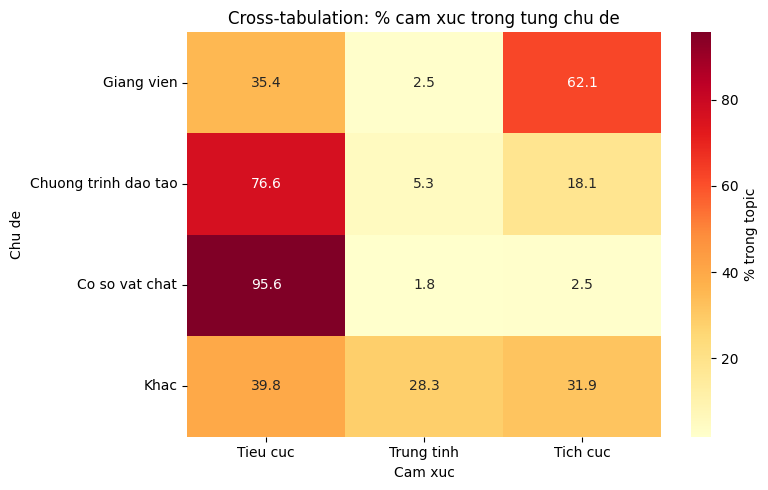

In [2]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data_with_topics(data_dir, split):
    split_dir = os.path.join(data_dir, split)
    with open(os.path.join(split_dir, 'sents.txt'), 'r', encoding='utf-8') as f:
        texts = [line.strip() for line in f.readlines()]
    with open(os.path.join(split_dir, 'sentiments.txt'), 'r', encoding='utf-8') as f:
        labels = [int(line.strip()) for line in f.readlines()]
    with open(os.path.join(split_dir, 'topics.txt'), 'r', encoding='utf-8') as f:
        topics = [int(line.strip()) for line in f.readlines()]
    return texts, labels, topics

topic_map = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}
label_map = {0: 'Tieu cuc', 1: 'Trung tinh', 2: 'Tich cuc'}

base_dir_candidates = [
    '/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis',
    '.',
]
data_dir = None
for c in base_dir_candidates:
    candidate = os.path.join(c, 'data', 'processed')
    if os.path.exists(candidate):
        data_dir = candidate
        break
if data_dir is None:
    raise FileNotFoundError('Khong tim thay data/processed')

all_rows = []
for split in ['train', 'validation', 'test']:
    _, labels, topics = load_data_with_topics(data_dir, split)
    all_rows.extend([{'split': split, 'label': y, 'topic': t} for y, t in zip(labels, topics)])

full_df = pd.DataFrame(all_rows)
print(f'Tong so mau: {len(full_df):,}')

# 1) Topic distribution
topic_counts = full_df['topic'].value_counts().sort_index()
topic_names = [topic_map[i] for i in topic_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(topic_counts.values, labels=topic_names, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Phan bo chu de (toan bo du lieu)')

bars = axes[1].bar(topic_names, topic_counts.values)
axes[1].set_title('So mau theo chu de')
axes[1].set_ylabel('So mau')
axes[1].grid(axis='y', alpha=0.3)
for b in bars:
    h = b.get_height()
    axes[1].text(b.get_x() + b.get_width()/2, h, f'{int(h):,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 2) Cross-tab sentiment within each topic
crosstab_count = pd.crosstab(full_df['topic'], full_df['label'])
crosstab_pct = pd.crosstab(full_df['topic'], full_df['label'], normalize='index') * 100
crosstab_count.index = [topic_map[i] for i in crosstab_count.index]
crosstab_count.columns = [label_map[i] for i in crosstab_count.columns]
crosstab_pct.index = [topic_map[i] for i in crosstab_pct.index]
crosstab_pct.columns = [label_map[i] for i in crosstab_pct.columns]

print('Bang dem sentiment x topic:')
display(crosstab_count)
print('Ti le % sentiment ben trong tung topic:')
display(crosstab_pct.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(crosstab_pct, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': '% trong topic'})
plt.title('Cross-tabulation: % cam xuc trong tung chu de')
plt.ylabel('Chu de')
plt.xlabel('Cam xuc')
plt.tight_layout()
plt.show()

## Topic Analysis: Phan bo chu de va cam xuc vat cheo

Phan nay bo sung thong ke theo topic tren toan bo du lieu (train + validation + test):
- Bieu do tron/cot phan bo chu de
- Cross-tabulation ti le Tich cuc/Trung tinh/Tieu cuc ben trong tung chu de

# PhoBERT + TF-IDF + SentiWordNet End-to-End

Notebook này fine-tune hybrid model theo hướng end-to-end với `gradual unfreezing` cho PhoBERT.


In [3]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [4]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, load_sentiwordnet, preprocess_vietnamese, extract_swn_features_extended_batch, SWN_EXTENDED_FEATURE_NAMES

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    SENTIWORDNET_FILE = os.path.join(BASE_DIR, 'data', 'sentiwordnet-dataset', 'VietSentiWordnet_Ver1.3.5.txt')
    MODEL_TYPE = 'PhoBERT_TF-IDF_Sentiwordnet'
    EXPERIMENT_TYPE = 'end_to_end_unfreezing'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 10
    EARLY_STOP_PATIENCE = 2
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 1e-4

    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True

    TFIDF_PROJ_DIM = 256
    SWN_PROJ_DIM = 64
    CLASSIFIER_HIDDEN_DIM = 256

    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4
    SELECTION_METRIC = 'f1_macro'

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)
assert os.path.exists(config.SENTIWORDNET_FILE), config.SENTIWORDNET_FILE
print(f'Results dir: {config.RESULTS_DIR}')
print(f'Device: {config.DEVICE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Gradual unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH - 1}, full@{config.FULL_UNFREEZE_EPOCH}+')


Results dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet/end_to_end_unfreezing/20260329_074056
Device: cuda
Epochs: 10
Gradual unfreezing: freeze<2, partial@2-3, full@4+


In [6]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'[{split_name}] total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count / len(labels) * 100:.2f}%)')


[Train] total=11426
  Negative: 5325 (46.60%)
  Neutral: 458 (4.01%)
  Positive: 5643 (49.39%)
[Validation] total=1583
  Negative: 705 (44.54%)
  Neutral: 73 (4.61%)
  Positive: 805 (50.85%)
[Test] total=3166
  Negative: 1409 (44.50%)
  Neutral: 167 (5.27%)
  Positive: 1590 (50.22%)


In [7]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(max_features=config.TFIDF_MAX_FEATURES, ngram_range=config.TFIDF_NGRAM_RANGE, min_df=config.TFIDF_MIN_DF, max_df=config.TFIDF_MAX_DF, sublinear_tf=config.TFIDF_SUBLINEAR_TF)
train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)
joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
print(f'TFIDF shapes: {train_tfidf.shape}, {val_tfidf.shape}, {test_tfidf.shape}')


TFIDF shapes: (11426, 5000), (1583, 5000), (3166, 5000)


In [8]:
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores).astype(np.float32)
val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores).astype(np.float32)
test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores).astype(np.float32)

swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn).astype(np.float32)
val_swn_scaled = swn_scaler.transform(val_swn).astype(np.float32)
test_swn_scaled = swn_scaler.transform(test_swn).astype(np.float32)
joblib.dump(swn_scaler, os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'))
print(f'SWN entries: {len(word_to_scores):,}')
print(f'SWN shape: {train_swn_scaled.shape}')


SWN entries: 1,227
SWN shape: (11426, 35)


In [9]:
class HybridDataset(Dataset):
    def __init__(self, texts, tfidf_features, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(str(self.texts[idx]), add_special_tokens=True, max_length=self.max_length, padding='max_length', truncation=True, return_tensors='pt')
        tfidf = self.tfidf_features[idx]
        if hasattr(tfidf, 'toarray'):
            tfidf = tfidf.toarray().ravel()
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'swn': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout=0.1):
        super().__init__()
        position = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe.unsqueeze(0))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        seq_len = x.size(1)
        return self.dropout(x + self.pe[:, :seq_len, :].to(dtype=x.dtype))

class PhoBERTTFIDFSentiWordNetHybrid(nn.Module):
    def __init__(self, model_name, tfidf_dim, swn_dim, num_classes, dropout=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size
        self.positional_encoding = PositionalEncoding(phobert_dim, max(self.phobert.config.max_position_embeddings, config.MAX_LENGTH), dropout)
        self.tfidf_proj = nn.Sequential(nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM), nn.SiLU(), nn.Dropout(dropout))
        self.swn_proj = nn.Sequential(nn.Linear(swn_dim, config.SWN_PROJ_DIM), nn.SiLU(), nn.Dropout(dropout))
        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM + config.SWN_PROJ_DIM
        self.fusion_proj = nn.Sequential(nn.Dropout(dropout), nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM), nn.SiLU())
        self.residual_block = nn.Sequential(nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM), nn.Dropout(dropout), nn.Linear(config.CLASSIFIER_HIDDEN_DIM, config.CLASSIFIER_HIDDEN_DIM), nn.SiLU(), nn.Dropout(dropout), nn.Linear(config.CLASSIFIER_HIDDEN_DIM, config.CLASSIFIER_HIDDEN_DIM))
        self.classifier = nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)

    def forward(self, input_ids, attention_mask, tfidf_features, swn_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = self.positional_encoding(outputs.last_hidden_state)
        mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
        phobert_emb = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        tfidf_emb = self.tfidf_proj(tfidf_features)
        swn_emb = self.swn_proj(swn_features)
        combined = torch.cat([phobert_emb, tfidf_emb, swn_emb], dim=1)
        fused = self.fusion_proj(combined)
        fused = fused + self.residual_block(fused)
        return self.classifier(fused)

def count_trainable_params(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFSentiWordNetHybrid(config.MODEL_NAME, config.TFIDF_MAX_FEATURES, train_swn_scaled.shape[1], config.NUM_CLASSES, config.DROPOUT).to(config.DEVICE)
print(f'Total params: {sum(param.numel() for param in model.parameters()):,}')
print(f'Initial trainable params: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 136,692,483
Initial trainable params: 136,692,483


In [10]:
train_dataset = HybridDataset(train_texts, train_tfidf, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')


Batches: train=715, val=99, test=198


In [11]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1, 2]), y=np.array(train_labels))
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

HEAD_MODULES = [model.tfidf_proj, model.swn_proj, model.fusion_proj, model.residual_block, model.classifier]

def get_training_stage(epoch_number):
    if epoch_number < config.PARTIAL_UNFREEZE_EPOCH:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'

def set_phobert_trainable_layers(model, stage):
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        for param in model.phobert.parameters():
            param.requires_grad = True

    for module in HEAD_MODULES:
        for param in module.parameters():
            param.requires_grad = True

def build_optimizer_and_scheduler(model, stage, epoch_number):
    phobert_lr = {'frozen': config.PHOBERT_LR_FROZEN, 'partial': config.PHOBERT_LR_PARTIAL, 'full': config.PHOBERT_LR_FULL}[stage]
    optimizer_groups = []
    phobert_params = [param for param in model.phobert.parameters() if param.requires_grad]
    head_params = [param for module in HEAD_MODULES for param in module.parameters() if param.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})
    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps

set_phobert_trainable_layers(model, 'frozen')
print(f'Class weights: {class_weights.tolist()}')
print(f'Trainable params after freeze setup: {count_trainable_params(model):,}')

Class weights: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze setup: 1,694,211


In [12]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        swn = batch['swn'].to(device)
        labels = batch['label'].to(device)
        logits = model(input_ids, attention_mask, tfidf, swn)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, accuracy, f1_macro

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            swn = batch['swn'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, tfidf, swn)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(all_labels, all_preds, labels=[0, 1, 2], zero_division=0)
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }


In [13]:
history = {'epoch': [], 'stage': [], 'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'phobert_lr': [], 'trainable_params': []}
best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('=' * 70)
print('START TRAINING WITH GRADUAL UNFREEZING')
print('=' * 70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)
    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')
    print(f'\nEpoch {epoch}/{config.EPOCHS}')
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)
    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))
    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> new best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> no improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)
print(f'Best epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')


START TRAINING WITH GRADUAL UNFREEZING

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=1,694,211

Epoch 1/10


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.9896 acc=0.6376 f1_macro=0.4652
Val    - loss=0.7173 acc=0.8054 f1_macro=0.6455 f1_neutral=0.2710
  -> new best model saved (val macro F1=0.6455)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=30,045,699

Epoch 2/10


...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0878 acc=0.9873 f1_macro=0.9720
Val    - loss=1.0145 acc=0.9394 f1_macro=0.8366 f1_neutral=0.6000
  -> no improvement, patience=1/2

Epoch 10/10


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0619 acc=0.9905 f1_macro=0.9798
Val    - loss=1.0407 acc=0.9368 f1_macro=0.8293 f1_neutral=0.5816
  -> no improvement, patience=2/2
  -> early stopping at epoch 10
Best epoch: 8, best stage: full, best val macro F1: 0.8461


In [14]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation classification report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))
print('\nTest classification report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))


Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation classification report:
              precision    recall  f1-score   support

    Negative       0.95      0.96      0.95       705
     Neutral       0.70      0.58      0.63        73
    Positive       0.95      0.96      0.96       805

    accuracy                           0.94      1583
   macro avg       0.87      0.83      0.85      1583
weighted avg       0.94      0.94      0.94      1583


Test classification report:
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95      1409
     Neutral       0.68      0.53      0.59       167
    Positive       0.94      0.96      0.95      1590

    accuracy                           0.93      3166
   macro avg       0.85      0.81      0.83      3166
weighted avg       0.93      0.93      0.93      3166



In [15]:
summary_df = pd.DataFrame([
    {'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'], 'F1_Weighted': val_results['f1_weighted'], 'F1_Negative': val_results['f1_per_class'][0], 'F1_Neutral': val_results['f1_per_class'][1], 'F1_Positive': val_results['f1_per_class'][2]},
    {'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'], 'F1_Weighted': test_results['f1_weighted'], 'F1_Negative': test_results['f1_per_class'][0], 'F1_Neutral': test_results['f1_per_class'][1], 'F1_Positive': test_results['f1_per_class'][2]},
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

experiment_summary = {
    'model_type': config.MODEL_TYPE,
    'experiment_type': config.EXPERIMENT_TYPE,
    'timestamp': config.TIMESTAMP,
    'epochs_configured': config.EPOCHS,
    'best_epoch': best_epoch,
    'best_stage': best_stage,
    'selection_metric': config.SELECTION_METRIC,
    'best_val_f1_macro': best_val_f1,
    'unfreezing_schedule': {
        'freeze_epochs': list(range(1, config.PARTIAL_UNFREEZE_EPOCH)),
        'partial_unfreeze_start_epoch': config.PARTIAL_UNFREEZE_EPOCH,
        'partial_unfreeze_last_n_layers': config.PARTIAL_UNFREEZE_LAST_N,
        'full_unfreeze_start_epoch': config.FULL_UNFREEZE_EPOCH
    },
    'validation': val_results,
    'test': test_results,
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF + SentiWordNet End-to-End\n')
    f.write('=' * 60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f"Test Accuracy: {test_results['accuracy']:.4f}\n")
    f.write(f"Test F1 Macro: {test_results['f1_macro']:.4f}\n")
    f.write(f"Test F1 Weighted: {test_results['f1_weighted']:.4f}\n")
    f.write(f"Test F1 Neutral: {test_results['f1_per_class'][1]:.4f}\n")
print(f'Saved outputs to: {config.RESULTS_DIR}')


,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,8,full,0.939987,0.846084,0.938669,0.950635,0.631579,0.956037
1,Test,8,full,0.931775,0.829755,0.929691,0.946252,0.592593,0.950421


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet/end_to_end_unfreezing/20260329_074056


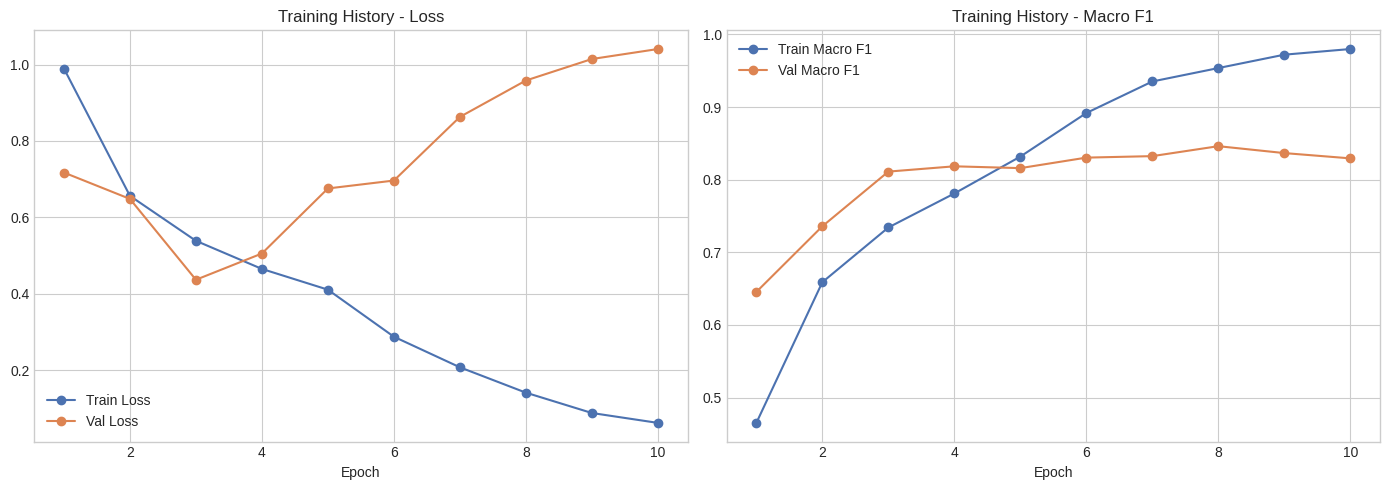

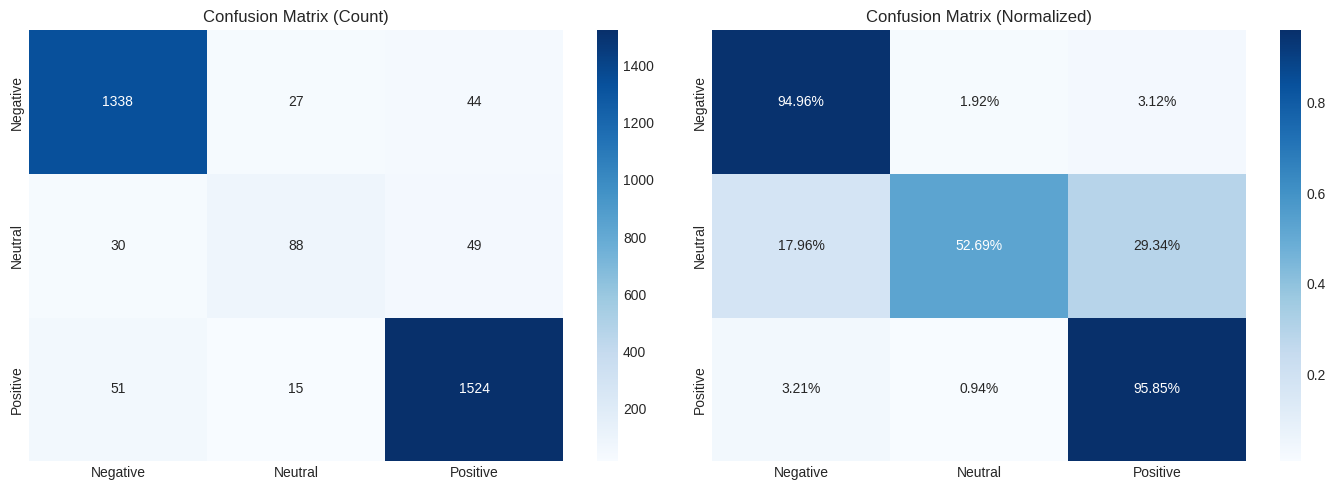

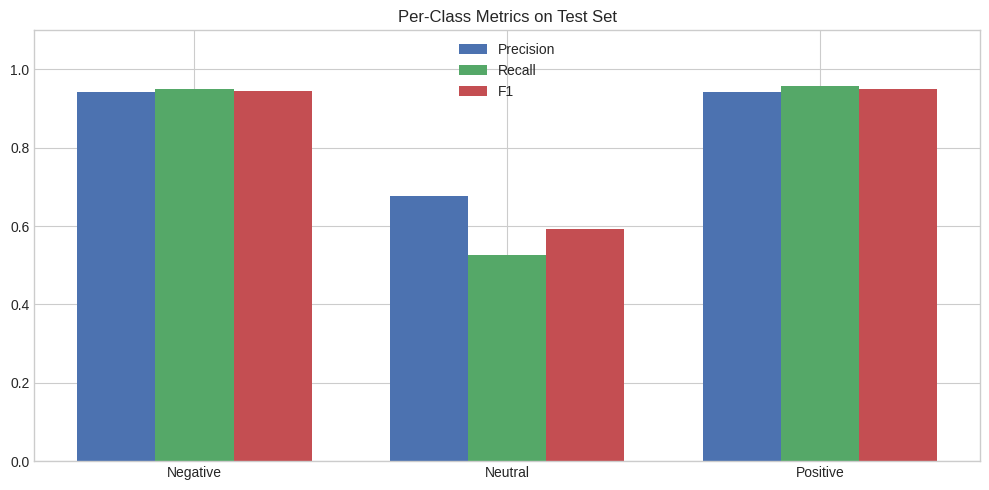

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train Loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val Loss')
axes[0].set_title('Training History - Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train Macro F1')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val Macro F1')
axes[1].set_title('Training History - Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(config.LABEL_MAP))
width = 0.25
ax.bar(x - width, test_results['precision_per_class'], width, label='Precision', color='#4C72B0')
ax.bar(x, test_results['recall_per_class'], width, label='Recall', color='#55A868')
ax.bar(x + width, test_results['f1_per_class'], width, label='F1', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(list(config.LABEL_MAP.values()))
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class Metrics on Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()


## Topic-wise Sentiment Analysis

Phan tich ket qua sentiment analysis theo tung chu de tren tap test.

In [17]:
def load_topics(data_dir, split):
    with open(os.path.join(data_dir, split, 'topics.txt'), 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines()]

TOPIC_MAP = {0: 'Giang vien', 1: 'Chuong trinh dao tao', 2: 'Co so vat chat', 3: 'Khac'}

test_topics = load_topics(config.DATA_DIR, 'test')
assert len(test_topics) == len(test_results['y_true']), f'Mismatch: topics={len(test_topics)} vs y_true={len(test_results["y_true"])}'

topic_df = pd.DataFrame({
    'topic': test_topics,
    'y_true': test_results['y_true'],
    'y_pred': test_results['y_pred'],
})

# === Per-topic metrics ===
topic_rows = []
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    p, r, f1, support = precision_recall_fscore_support(
        sub['y_true'], sub['y_pred'], labels=[0, 1, 2], zero_division=0
    )
    topic_rows.append({
        'topic_id': int(topic_id),
        'topic_name': TOPIC_MAP.get(int(topic_id), str(topic_id)),
        'samples': int(len(sub)),
        'accuracy': float(accuracy_score(sub['y_true'], sub['y_pred'])),
        'f1_macro': float(f1_score(sub['y_true'], sub['y_pred'], average='macro', zero_division=0)),
        'f1_weighted': float(f1_score(sub['y_true'], sub['y_pred'], average='weighted', zero_division=0)),
        'f1_negative': float(f1[0]),
        'f1_neutral': float(f1[1]),
        'f1_positive': float(f1[2]),
    })

topic_metrics_df = pd.DataFrame(topic_rows).sort_values('topic_id')
print('=== Topic-wise Metrics (Test Set) ===')
display(topic_metrics_df)

# === Per-topic classification reports ===
for topic_id in sorted(topic_df['topic'].unique()):
    sub = topic_df[topic_df['topic'] == topic_id]
    print(f"\n--- Topic {topic_id} ({TOPIC_MAP.get(int(topic_id), str(topic_id))}) - {len(sub)} samples ---")
    print(classification_report(sub['y_true'], sub['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

# Save
topic_metrics_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_metrics.csv'), index=False)
topic_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'topic_predictions_test.csv'), index=False)
print(f'\nSaved: topic_metrics.csv, topic_predictions_test.csv')

=== Topic-wise Metrics (Test Set) ===


,topic_id,topic_name,samples,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive
0,0,Giang vien,2290,0.948035,0.829219,0.946117,0.946574,0.576000,0.965084
1,1,Chuong trinh dao tao,572,0.893357,0.764698,0.889973,0.947115,0.512195,0.834783
2,2,Co so vat chat,145,0.986207,0.832121,0.986194,0.996364,0.666667,0.833333
3,3,Khac,159,0.786164,0.777435,0.785660,0.830769,0.689655,0.811881



--- Topic 0 (Giang vien) - 2290 samples ---
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.95       791
     Neutral       0.71      0.49      0.58        74
    Positive       0.96      0.97      0.97      1425

    accuracy                           0.95      2290
   macro avg       0.87      0.80      0.83      2290
weighted avg       0.95      0.95      0.95      2290


--- Topic 1 (Chuong trinh dao tao) - 572 samples ---
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95       416
     Neutral       0.60      0.45      0.51        47
    Positive       0.79      0.88      0.83       109

    accuracy                           0.89       572
   macro avg       0.78      0.76      0.76       572
weighted avg       0.89      0.89      0.89       572


--- Topic 2 (Co so vat chat) - 145 samples ---
              precision    recall  f1-score   support

    Negative       1.00      0.99   

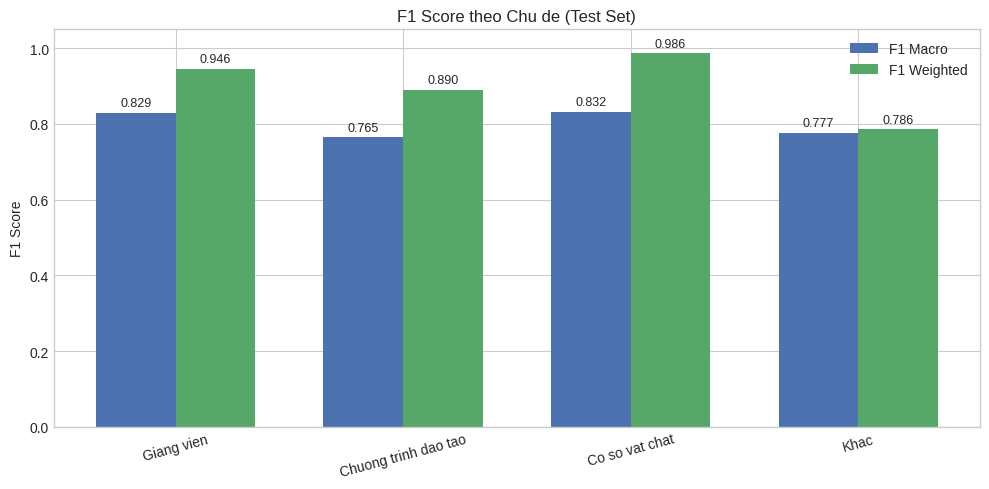

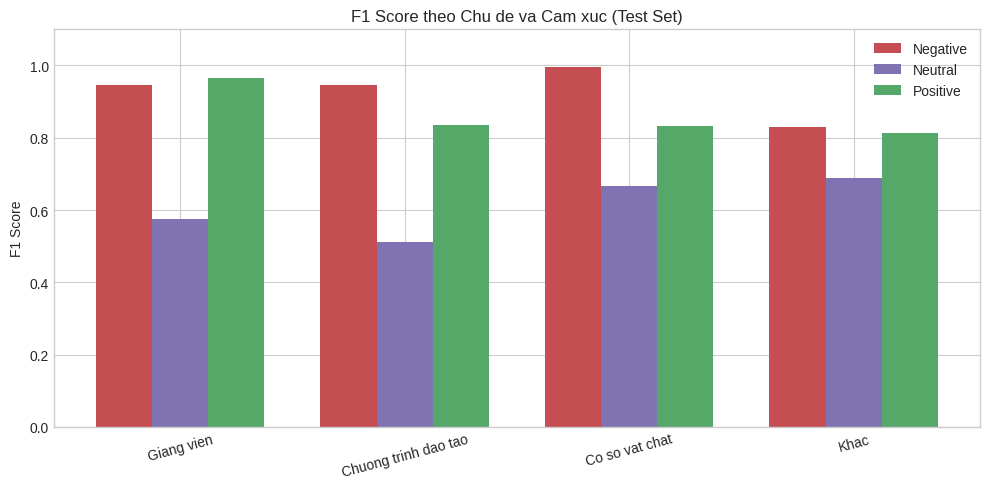

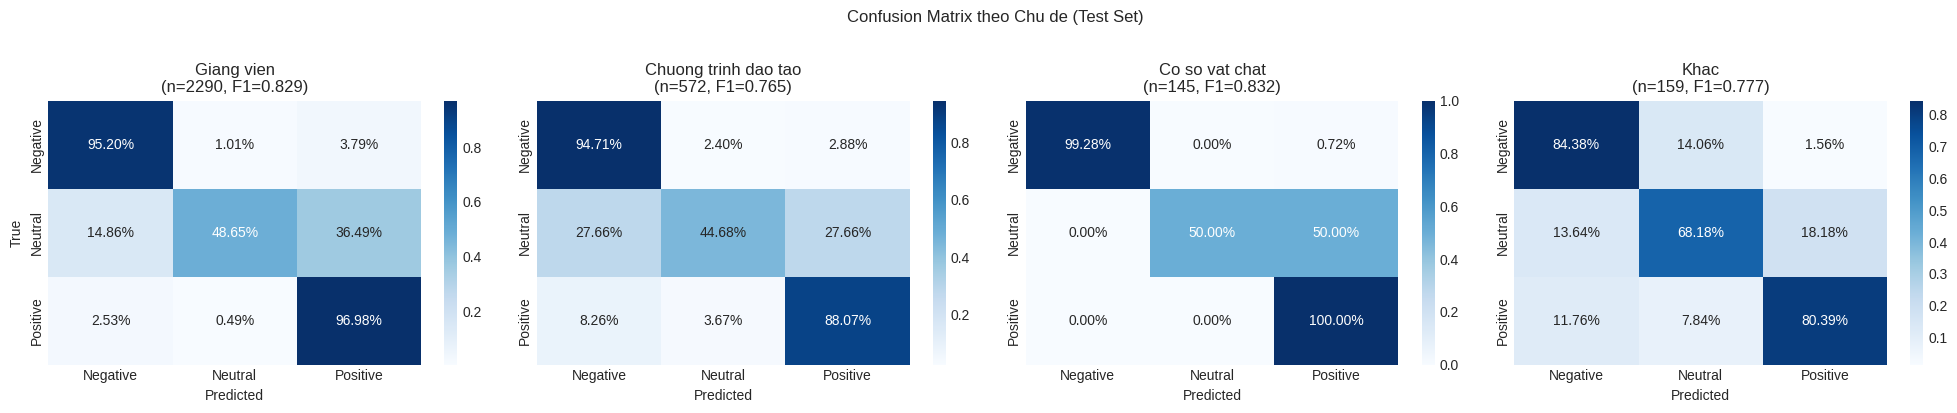

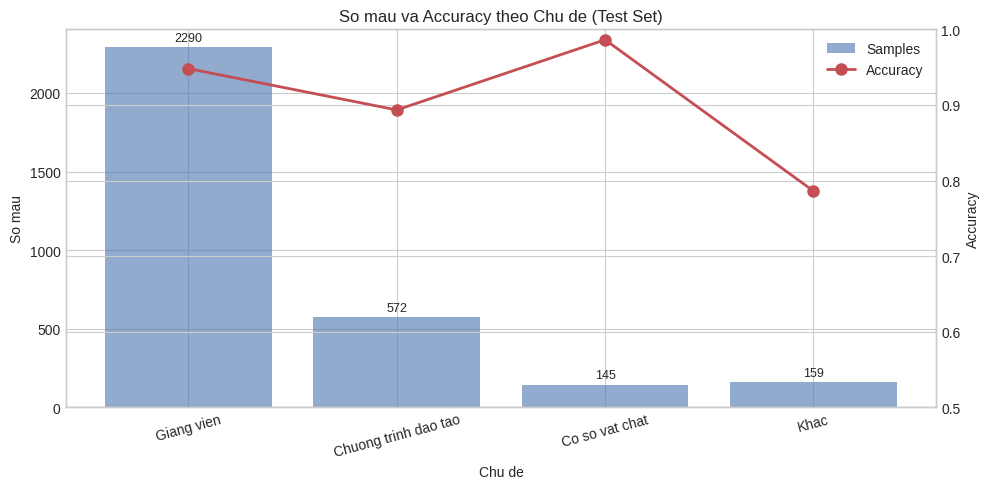

Da luu tat ca bieu do topic-wise vao: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet/end_to_end_unfreezing/20260329_074056/visualizations


In [18]:
# === Topic-wise visualizations ===

# 1) F1 macro/weighted per topic
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.35
bars1 = ax.bar(x - width/2, topic_metrics_df['f1_macro'], width, label='F1 Macro', color='#4C72B0')
bars2 = ax.bar(x + width/2, topic_metrics_df['f1_weighted'], width, label='F1 Weighted', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('F1 Score theo Chu de (Test Set)')
ax.legend()
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_f1_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

# 2) Per-topic per-sentiment F1
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(topic_metrics_df))
width = 0.25
ax.bar(x - width, topic_metrics_df['f1_negative'], width, label='Negative', color='#C44E52')
ax.bar(x, topic_metrics_df['f1_neutral'], width, label='Neutral', color='#8172B2')
ax.bar(x + width, topic_metrics_df['f1_positive'], width, label='Positive', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score theo Chu de va Cam xuc (Test Set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_sentiment_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

# 3) Cross-tab: predicted vs actual sentiment per topic (confusion matrix heatmap per topic)
fig, axes = plt.subplots(1, len(topic_metrics_df), figsize=(5 * len(topic_metrics_df), 4))
label_names = list(config.LABEL_MAP.values())
for i, row in topic_metrics_df.iterrows():
    sub = topic_df[topic_df['topic'] == row['topic_id']]
    cm_topic = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0, 1, 2])
    cm_topic_norm = cm_topic.astype(float) / cm_topic.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_topic_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[i])
    axes[i].set_title(f"{row['topic_name']}\n(n={row['samples']}, F1={row['f1_macro']:.3f})")
    if i == 0:
        axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')
plt.suptitle('Confusion Matrix theo Chu de (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

# 4) Sample count + accuracy per topic
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
bars = ax1.bar(x, topic_metrics_df['samples'], color='#4C72B0', alpha=0.6, label='Samples')
ax1.set_ylabel('So mau')
ax1.set_xlabel('Chu de')
ax1.set_xticks(x)
ax1.set_xticklabels(topic_metrics_df['topic_name'], rotation=15)
line = ax2.plot(x, topic_metrics_df['accuracy'], 'o-', color='#C44E52', linewidth=2, markersize=8, label='Accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('So mau va Accuracy theo Chu de (Test Set)')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'topic_samples_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Da luu tat ca bieu do topic-wise vao:', config.VISUALIZATIONS_DIR)